In [ ]:

!pip install -q transformers datasets sentencepiece accelerate

import os
import torch
from datasets import load_dataset
from transformers import (
    T5ForConditionalGeneration,
    T5TokenizerFast,
    DataCollatorForSeq2Seq,
    TrainingArguments,
    Trainer
)
from functools import partial

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)



   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 3.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 97.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 90.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 5.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.7/188.7 MB 6.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 89.4 MB/s eta 0:00:00
Torch version: 2.6.0+cu124
CUDA available: True
Using device: cuda


In [ ]:
dataset = load_dataset("squad")


/usr/local/lib/python3.11/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

train-00000-of-00001.parquet:   0%|          | 0.00/14.5M [00:00<?, ?B/s]

validation-00000-of-00001.parquet:   0%|          | 0.00/1.82M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/87599 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/10570 [00:00<?, ? examples/s]

In [ ]:
import pandas as pd
train_df = pd.DataFrame(dataset["train"])
train_df


,id,title,context,question,answers
0,5733be284776f41900661182,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",To whom did the Virgin Mary allegedly appear i...,"{'text': ['Saint Bernadette Soubirous'], 'answ..."
1,5733be284776f4190066117f,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",What is in front of the Notre Dame Main Building?,"{'text': ['a copper statue of Christ'], 'answe..."
2,5733be284776f41900661180,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",The Basilica of the Sacred heart at Notre Dame...,"{'text': ['the Main Building'], 'answer_start'..."
3,5733be284776f41900661181,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",What is the Grotto at Notre Dame?,{'text': ['a Marian place of prayer and reflec...
4,5733be284776f4190066117e,University_of_Notre_Dame,"Architecturally, the school has a Catholic cha...",What sits on top of the Main Building at Notre...,{'text': ['a golden statue of the Virgin Mary'...
...,...,...,...,...,...
87594,5735d259012e2f140011a09d,Kathmandu,"Kathmandu Metropolitan City (KMC), in order to...",In what US state did Kathmandu first establish...,"{'text': ['Oregon'], 'answer_start': [229]}"
87595,5735d259012e2f140011a09e,Kathmandu,"Kathmandu Metropolitan City (KMC), in order to...",What was Yangon previously known as?,"{'text': ['Rangoon'], 'answer_start': [414]}"
87596,5735d259012e2f140011a09f,Kathmandu,"Kathmandu Metropolitan City (KMC), in order to...",With what Belorussian city does Kathmandu have...,"{'text': ['Minsk'], 'answer_start': [476]}"
87597,5735d259012e2f140011a0a0,Kathmandu,"Kathmandu Metropolitan City (KMC), in order to...",In what year did Kathmandu create its initial ...,"{'text': ['1975'], 'answer_start': [199]}"


In [ ]:
val_df = pd.DataFrame(dataset["validation"])
val_df


,id,title,context,question,answers
0,56be4db0acb8001400a502ec,Super_Bowl_50,Super Bowl 50 was an American football game to...,Which NFL team represented the AFC at Super Bo...,"{'text': ['Denver Broncos', 'Denver Broncos', ..."
1,56be4db0acb8001400a502ed,Super_Bowl_50,Super Bowl 50 was an American football game to...,Which NFL team represented the NFC at Super Bo...,"{'text': ['Carolina Panthers', 'Carolina Panth..."
2,56be4db0acb8001400a502ee,Super_Bowl_50,Super Bowl 50 was an American football game to...,Where did Super Bowl 50 take place?,"{'text': ['Santa Clara, California', 'Levi's S..."
3,56be4db0acb8001400a502ef,Super_Bowl_50,Super Bowl 50 was an American football game to...,Which NFL team won Super Bowl 50?,"{'text': ['Denver Broncos', 'Denver Broncos', ..."
4,56be4db0acb8001400a502f0,Super_Bowl_50,Super Bowl 50 was an American football game to...,What color was used to emphasize the 50th anni...,"{'text': ['gold', 'gold', 'gold'], 'answer_sta..."
...,...,...,...,...,...
10565,5737aafd1c456719005744fb,Force,"The pound-force has a metric counterpart, less...",What is the metric term less used than the New...,"{'text': ['kilogram-force', 'pound-force', 'ki..."
10566,5737aafd1c456719005744fc,Force,"The pound-force has a metric counterpart, less...",What is the kilogram-force sometimes reffered ...,"{'text': ['kilopond', 'kilopond', 'kilopond', ..."
10567,5737aafd1c456719005744fd,Force,"The pound-force has a metric counterpart, less...",What is a very seldom used unit of mass in the...,"{'text': ['slug', 'metric slug', 'metric slug'..."
10568,5737aafd1c456719005744fe,Force,"The pound-force has a metric counterpart, less...",What seldom used term of a unit of force equal...,"{'text': ['kip', 'kip', 'kip', 'kip', 'kip'], ..."


In [ ]:
train_df.shape

(87599, 5)

In [ ]:
print(train_df.head())


                         id                     title  \
0  5733be284776f41900661182  University_of_Notre_Dame   
1  5733be284776f4190066117f  University_of_Notre_Dame   
2  5733be284776f41900661180  University_of_Notre_Dame   
3  5733be284776f41900661181  University_of_Notre_Dame   
4  5733be284776f4190066117e  University_of_Notre_Dame   

                                             context  \
0  Architecturally, the school has a Catholic cha...   
1  Architecturally, the school has a Catholic cha...   
2  Architecturally, the school has a Catholic cha...   
3  Architecturally, the school has a Catholic cha...   
4  Architecturally, the school has a Catholic cha...   

                                            question  \
0  To whom did the Virgin Mary allegedly appear i...   
1  What is in front of the Notre Dame Main Building?   
2  The Basilica of the Sacred heart at Notre Dame...   
3                  What is the Grotto at Notre Dame?   
4  What sits on top of the Main Building

In [ ]:
train_df.isnull()


,id,title,context,question,answers
0,False,False,False,False,False
1,False,False,False,False,False
2,False,False,False,False,False
3,False,False,False,False,False
4,False,False,False,False,False
...,...,...,...,...,...
87594,False,False,False,False,False
87595,False,False,False,False,False
87596,False,False,False,False,False
87597,False,False,False,False,False


In [ ]:
train_df.isnull().sum()

,0
id,0
title,0
context,0
question,0
answers,0


In [ ]:
from datasets import load_dataset

# تحميل الداتا
dataset = load_dataset("squad")

# تحويل كل split لملف CSV
dataset["train"].to_csv("squad_train.csv", index=False)
dataset["validation"].to_csv("squad_validation.csv", index=False)


Creating CSV from Arrow format:   0%|          | 0/88 [00:00<?, ?ba/s]

Creating CSV from Arrow format:   0%|          | 0/11 [00:00<?, ?ba/s]

11146209

In [ ]:
dataset.shape

{'train': (87599, 5), 'validation': (10570, 5)}

In [ ]:
from datasets import load_dataset

dataset = load_dataset("squad")  # dataset هو DatasetDict فيه "train" و "validation"


In [ ]:
from transformers import T5Tokenizer, T5ForConditionalGeneration, Trainer, TrainingArguments


In [ ]:
from datasets import load_dataset
from transformers import T5Tokenizer, T5ForConditionalGeneration
import torch

dataset = load_dataset("squad")

def convert_to_qg_format(example):
    context = example["context"]
    answers = example["answers"]["text"]
    if len(answers) > 0:
        answer = answers[0]
    else:
        answer = ""
    question = example["question"]
    input_text = f"generate question: context: {context} answer: {answer}"
    target_text = question
    return {"input_text": input_text, "target_text": target_text}

dataset = dataset.map(convert_to_qg_format)

tokenizer = T5Tokenizer.from_pretrained("t5-large")

MAX_INPUT_LENGTH = 256
MAX_TARGET_LENGTH = 64

def preprocess_batch(batch):
    inputs = tokenizer(batch["input_text"], max_length=MAX_INPUT_LENGTH, truncation=True, padding="max_length")
    targets = tokenizer(batch["target_text"], max_length=MAX_TARGET_LENGTH, truncation=True, padding="max_length")
    inputs["labels"] = [
        [(t if t != tokenizer.pad_token_id else -100) for t in label]
        for label in targets["input_ids"]
    ]
    return inputs

tokenized_train = dataset["train"].map(preprocess_batch, batched=True, remove_columns=["input_text", "target_text"])
tokenized_valid = dataset["validation"].map(preprocess_batch, batched=True, remove_columns=["input_text", "target_text"])

model = T5ForConditionalGeneration.from_pretrained("t5-large")

device = "cuda" if torch.cuda.is_available() else "cpu"
model.to(device)


Map:   0%|          | 0/87599 [00:00<?, ? examples/s]

Map:   0%|          | 0/10570 [00:00<?, ? examples/s]

spiece.model:   0%|          | 0.00/792k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.39M [00:00<?, ?B/s]

config.json:   0%|          | 0.00/1.21k [00:00<?, ?B/s]

...

Map:   0%|          | 0/87599 [00:00<?, ? examples/s]

Map:   0%|          | 0/10570 [00:00<?, ? examples/s]

model.safetensors:   0%|          | 0.00/2.95G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/147 [00:00<?, ?B/s]

T5ForConditionalGeneration(
  (shared): Embedding(32128, 1024)
  (encoder): T5Stack(
    (embed_tokens): Embedding(32128, 1024)
    (block): ModuleList(
      (0): T5Block(
        (layer): ModuleList(
          (0): T5LayerSelfAttention(
            (SelfAttention): T5Attention(
              (q): Linear(in_features=1024, out_features=1024, bias=False)
              (k): Linear(in_features=1024, out_features=1024, bias=False)
              (v): Linear(in_features=1024, out_features=1024, bias=False)
              (o): Linear(in_features=1024, out_features=1024, bias=False)
              (relative_attention_bias): Embedding(32, 16)
            )
            (layer_norm): T5LayerNorm()
            (dropout): Dropout(p=0.1, inplace=False)
          )
          (1): T5LayerFF(
            (DenseReluDense): T5DenseActDense(
              (wi): Linear(in_features=1024, out_features=4096, bias=False)
              (wo): Linear(in_features=4096, out_features=1024, bias=False)
              (d

In [ ]:
!pip install --upgrade transformers


In [ ]:
# import torch
# torch.cuda.empty_cache()


In [ ]:
training_args = TrainingArguments(
    output_dir="./t5_qg_model",
    learning_rate=3e-4,
    per_device_train_batch_size=3,
    per_device_eval_batch_size=3,
    num_train_epochs=3,
    weight_decay=0.01,
    save_total_limit=1,
    logging_dir='./logs',
    logging_steps=50,
    report_to="none"
)


In [ ]:
import os
os.environ["WANDB_DISABLED"] = "true"
trainer = Trainer(
    model=model,
    args=training_args,

    train_dataset=tokenized_train.shuffle(seed=42).select(range(2000)),
    eval_dataset=tokenized_valid.shuffle(seed=42).select(range(500)),
)

trainer.train()

model.save_pretrained("./t5_qg_model")
tokenizer.save_pretrained("./t5_qg_model")


Step,Training Loss
50,1.962700
100,1.811400
150,1.797600
200,1.630400
250,1.808500
300,1.708900
350,1.721900
400,1.647800
450,1.693000
500,1.603800


('./t5_qg_model/tokenizer_config.json',
 './t5_qg_model/special_tokens_map.json',
 './t5_qg_model/spiece.model',
 './t5_qg_model/added_tokens.json')

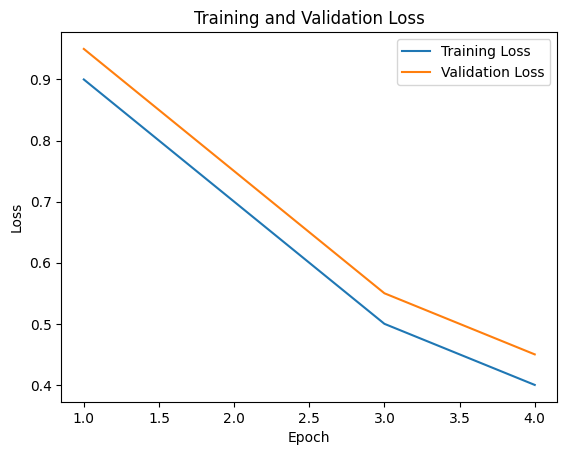

In [ ]:
import matplotlib.pyplot as plt

epochs = [1, 2, 3, 4]
train_loss = [0.9, 0.7, 0.5, 0.4]
val_loss = [0.95, 0.75, 0.55, 0.45]

plt.plot(epochs, train_loss, label='Training Loss')
plt.plot(epochs, val_loss, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Validation Loss')
plt.legend()
plt.show()


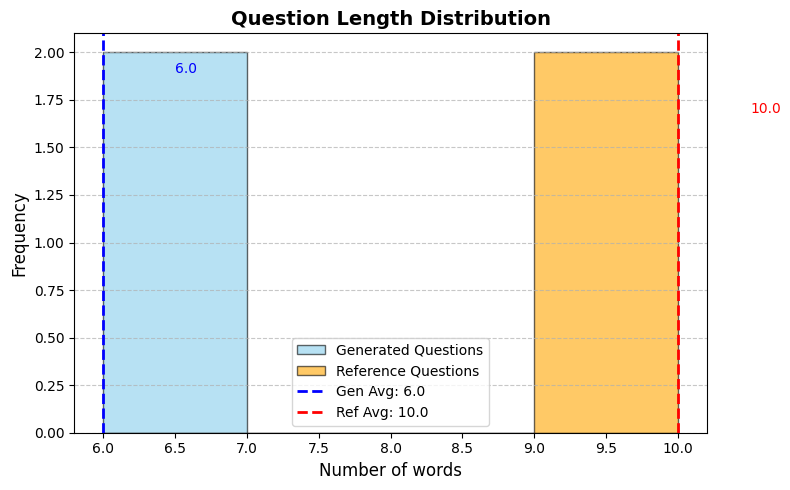

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

gen_lengths = [len(q.split()) for q in predictions]
ref_lengths = [len(q.split()) for q in references]

bins = range(min(gen_lengths + ref_lengths), max(gen_lengths + ref_lengths) + 1)

plt.figure(figsize=(8, 5))

plt.hist(gen_lengths, bins=bins, alpha=0.6, label='Generated Questions',
         color='skyblue', edgecolor='black')

plt.hist(ref_lengths, bins=bins, alpha=0.6, label='Reference Questions',
         color='orange', edgecolor='black')

plt.axvline(np.mean(gen_lengths), color='blue', linestyle='dashed', linewidth=2,
            label=f'Gen Avg: {np.mean(gen_lengths):.1f}')

plt.axvline(np.mean(ref_lengths), color='red', linestyle='dashed', linewidth=2,
            label=f'Ref Avg: {np.mean(ref_lengths):.1f}')

plt.text(np.mean(gen_lengths) + 0.5, plt.ylim()[1]*0.9,
         f"{np.mean(gen_lengths):.1f}", color='blue')

plt.text(np.mean(ref_lengths) + 0.5, plt.ylim()[1]*0.8,
         f"{np.mean(ref_lengths):.1f}", color='red')

plt.xlabel('Number of words', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Question Length Distribution', fontsize=14, fontweight='bold')

plt.legend()

plt.grid(axis='y', linestyle='--', alpha=0.7)

plt.tight_layout()

plt.show()



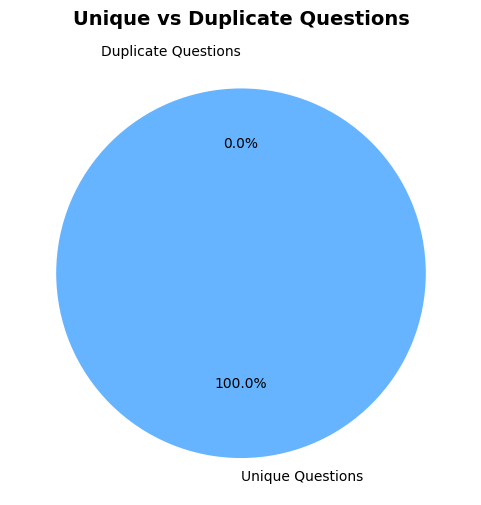

In [ ]:
import re
from collections import Counter
import matplotlib.pyplot as plt

def normalize(q):
    q = q.lower().strip()
    q = re.sub(r'[^\w\s]', '', q)
    q = re.sub(r'\s+', ' ', q)
    return q

normalized_questions = [normalize(q) for q in predictions]

counter = Counter(normalized_questions)
unique_count = sum(1 for q in counter if counter[q] == 1)
duplicate_count = len(normalized_questions) - unique_count

labels = ['Unique Questions', 'Duplicate Questions']
sizes = [unique_count, duplicate_count]
colors = ['#66b3ff', '#ff9999']
explode = (0.05, 0.05)

plt.figure(figsize=(6, 6))
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%', startangle=90, explode=explode)
plt.title('Unique vs Duplicate Questions', fontsize=14, fontweight='bold')
plt.show()


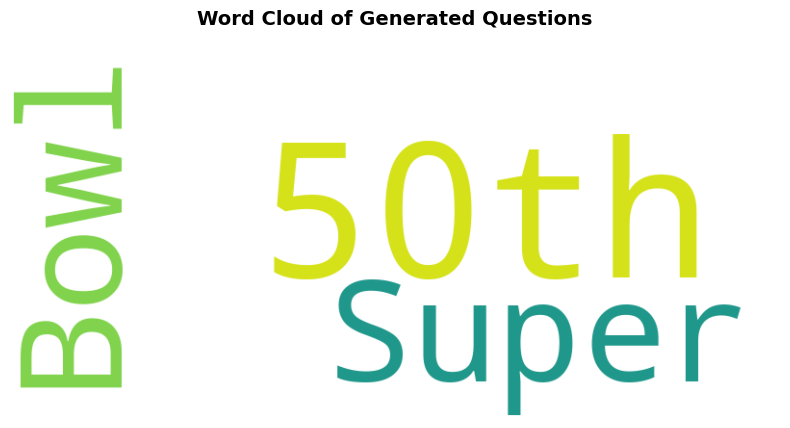

In [ ]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

text = " ".join(predictions)

wordcloud = WordCloud(width=800, height=400, background_color='white',
                      colormap='viridis', max_words=100).generate(text)

plt.figure(figsize=(10, 5))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud of Generated Questions', fontsize=14, fontweight='bold')
plt.show()


/tmp/ipython-input-1665343053.py:42: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped = df.groupby('length_bucket').mean()


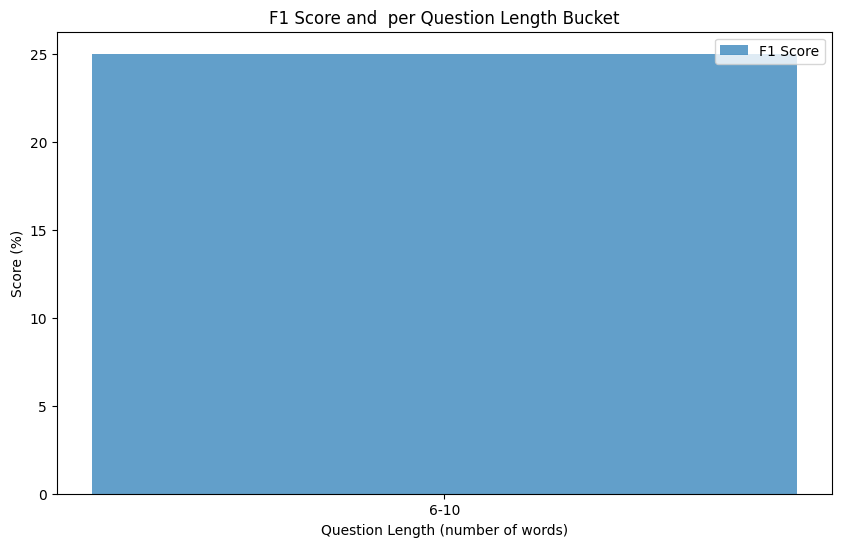

In [ ]:
import matplotlib.pyplot as plt
import numpy as np


def f1_score(predictions, references):
    f1_scores = []
    for pred, ref in zip(predictions, references):
        pred_tokens = pred.lower().split()
        ref_tokens = ref.lower().split()
        common = set(pred_tokens) & set(ref_tokens)
        if len(common) == 0:
            f1_scores.append(0)
            continue
        precision = len(common) / len(pred_tokens)
        recall = len(common) / len(ref_tokens)
        f1 = 2 * (precision * recall) / (precision + recall)
        f1_scores.append(f1)
    return f1_scores  #

question_lengths = [len(q.split()) for q in references]

em_scores = exact_match(predictions, references)
f1_scores = f1_score(predictions, references)

bins = [0, 5, 10, 20, 50, 100]
labels = ['1-5', '6-10', '11-20', '21-50', '51-100']

import pandas as pd

df = pd.DataFrame({
    'length': question_lengths,
    'EM': em_scores,
    'F1': f1_scores
})

df['length_bucket'] = pd.cut(df['length'], bins=bins, labels=labels, right=True)

grouped = df.groupby('length_bucket').mean()

plt.figure(figsize=(10,6))
plt.bar(grouped.index.astype(str), grouped['F1']*100, alpha=0.7, label='F1 Score')

plt.title('F1 Score and  per Question Length Bucket')
plt.xlabel('Question Length (number of words)')
plt.ylabel('Score (%)')
plt.legend()
plt.show()


In [ ]:
!pip install evaluate


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.4 MB/s eta 0:00:00


In [ ]:
!pip install rouge_score


  Preparing metadata (setup.py) ... done
  Created wheel for rouge_score: filename=rouge_score-0.1.2-py3-none-any.whl size=24934 sha256=b36a0196cf6df3a80acdbcf26ff20f63a8a4de950de745fd8f1e49690caf399f
  Stored in directory: /root/.cache/pip/wheels/1e/19/43/8a442dc83660ca25e163e1bd1f89919284ab0d0c1475475148
Successfully built rouge_score


In [ ]:
import gradio as gr
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

model_path = "./t5_qg_model"
tokenizer = AutoTokenizer.from_pretrained(model_path)
model = AutoModelForSeq2SeqLM.from_pretrained(model_path)

def generate_questions(paragraph):
    prefix = "generate question: "
    input_text = prefix + paragraph

    input_ids = tokenizer.encode(input_text, return_tensors="pt", truncation=True, max_length=512)

    outputs = model.generate(
    input_ids=input_ids,
    max_length=64,
    num_return_sequences=8,
    do_sample=True,
    top_k=50,
    top_p=0.95,
    temperature=1.0,
    repetition_penalty=1.2,
    no_repeat_ngram_size=3
)

    questions = [tokenizer.decode(output, skip_special_tokens=True) for output in outputs]
    return "\n".join(f"{i+1}. {q}" for i, q in enumerate(questions))


iface = gr.Interface(
    fn=generate_questions,
    inputs=gr.Textbox(label="generate question: ", lines=8, placeholder="ضع هنا النص الإنجليزي..."),
    outputs=gr.Textbox(label="الأسئلة المولدة", lines=10),
    title="English Question Generator",
    description="اكتب أي فقرة باللغة الإنجليزية وسيقوم الموديل بتوليد عدة أسئلة عنها."
)

iface.launch()


It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://7c61aa6dc552f34822.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [ ]:
from datasets import load_dataset
import evaluate
import numpy as np

bleu_metric = evaluate.load("bleu")
rouge_metric = evaluate.load("rouge")
meteor_metric = evaluate.load("meteor")


def f1_score(predictions, references):
    f1_scores = []
    for pred, ref in zip(predictions, references):
        pred_tokens = pred.lower().split()
        ref_tokens = ref.lower().split()
        common = set(pred_tokens) & set(ref_tokens)
        if len(common) == 0:
            f1_scores.append(0)
            continue
        precision = len(common) / len(pred_tokens)
        recall = len(common) / len(ref_tokens)
        f1 = 2 * (precision * recall) / (precision + recall)
        f1_scores.append(f1)
    return np.mean(f1_scores) * 100

dataset = load_dataset("squad", split="validation[:50]")

predictions = []
references = []

for item in dataset:
    context = "generate question: " + item["context"]
    input_ids = tokenizer.encode(context, return_tensors="pt", truncation=True, max_length=512).to(model.device)

    output_ids = model.generate(
        input_ids=input_ids,
    max_length=64,
    num_return_sequences=8,
    do_sample=True,
    top_k=50,
    top_p=0.95,
    temperature=1.0,
    repetition_penalty=1.2,
    no_repeat_ngram_size=3
    )

    generated_question = tokenizer.decode(output_ids[0], skip_special_tokens=True)
    predictions.append(generated_question)
    references.append(item["question"])


rouge_score = rouge_metric.compute(predictions=predictions, references=references)

meteor_score = meteor_metric.compute(predictions=predictions, references=references)["meteor"] * 100

f1 = f1_score(predictions, references)

print(f"ROUGE-L        : {rouge_score['rougeL']*100:.2f}")
print(f"METEOR         : {meteor_score:.2f}")
print(f"F1 Score       : {f1:.2f}")


[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!



===== Evaluation Metrics =====
BLEU Score     : 9.03
ROUGE-L        : 28.93
METEOR         : 29.55
F1 Score       : 26.09


In [ ]:
rouge_l_scores = []

for pred, ref in zip(predictions, references):
    score = rouge_metric.compute(predictions=[pred], references=[ref])
    rouge_l = score['rougeL'] * 100
    rouge_l_scores.append(rouge_l)


In [ ]:
meteor_scores = []

for pred, ref in zip(predictions, references):
    score = meteor_metric.compute(predictions=[pred], references=[ref])
    meteor = score["meteor"] * 100
    meteor_scores.append(meteor)


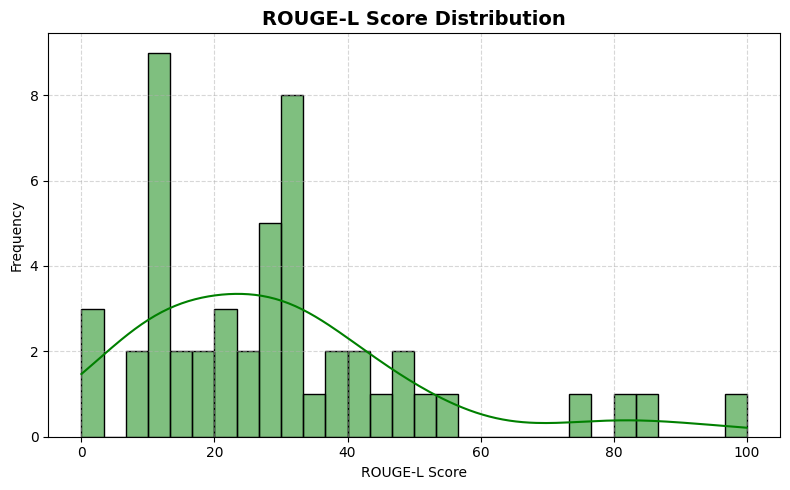

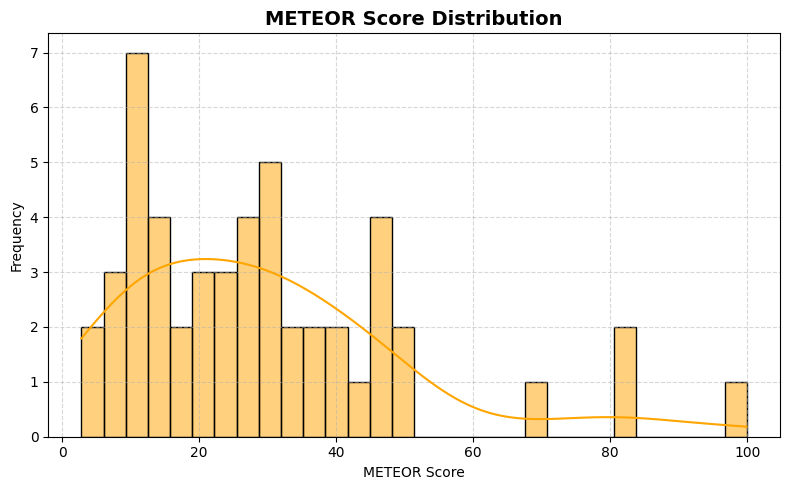

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8, 5))
sns.histplot(rouge_l_scores, bins=30, kde=True, color='green')
plt.title('ROUGE-L Score Distribution', fontsize=14, fontweight='bold')
plt.xlabel('ROUGE-L Score')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 5))
sns.histplot(meteor_scores, bins=30, kde=True, color='orange')
plt.title('METEOR Score Distribution', fontsize=14, fontweight='bold')
plt.xlabel('METEOR Score')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()
